# 03b – Gaussian DEPT Similarity: σ Parameter Optimisation

This notebook sweeps the `sigma` (σ) parameter of the Gaussian spectral representation
and evaluates Hits@K retrieval performance on the experimental NMRShiftDB2 validation set.

## 0 · Imports

In [1]:
import ast
import os

# Silence tqdm progress bars (incl. the library prefilter's) — the parallel
# sweep runs in a few minutes, so the bars add noise without much value.
os.environ["TQDM_DISABLE"] = "1"

from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from dept_similarity.constants import PROCESSED_DATA_DIR, RESULTS_DIR
from dept_similarity.gaussian_vector import generate_gaussian_vector
from dept_similarity.prepare import prefilter_pairs_by_peak_overlap

tqdm.pandas()

## 1 · Load data

Loads `library_data.parquet` and `experimental_validation_set.parquet`, normalizes
`signed_shifts` to float arrays, then builds a reproducible random query subset
from unique molecules (`QUERY_SUBSET_SIZE`, `RANDOM_SEED`).

In [2]:
library_spectra_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/library_data.parquet")
query_spectra_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/experimental_validation_set.parquet")


def _to_float_array(v):
    if isinstance(v, np.ndarray):
        return v.astype(np.float32, copy=False)
    if isinstance(v, list):
        return np.asarray(v, dtype=np.float32)
    if isinstance(v, str):
        v = v.strip()
        if not v:
            return np.asarray([], dtype=np.float32)
        try:
            parsed = ast.literal_eval(v)
        except (ValueError, SyntaxError):
            parsed = []
        return np.asarray(parsed, dtype=np.float32)
    if pd.isna(v):
        return np.asarray([], dtype=np.float32)
    return np.asarray(v, dtype=np.float32)


library_spectra_df["signed_shifts"] = library_spectra_df["signed_shifts"].map(_to_float_array)
query_spectra_df["signed_shifts"] = query_spectra_df["signed_shifts"].map(_to_float_array)

# None → use the full validation set (all unique-molecule queries). Set an int to subsample.
QUERY_SUBSET_SIZE = None
RANDOM_SEED = 42

query_unique_df = query_spectra_df.drop_duplicates(subset=["inchikey"]).copy()
if QUERY_SUBSET_SIZE is not None:
    if len(query_unique_df) < QUERY_SUBSET_SIZE:
        raise ValueError(
            f"Need at least {QUERY_SUBSET_SIZE} unique query molecules, found {len(query_unique_df)}"
        )
    query_spectra_df = query_unique_df.sample(
        n=QUERY_SUBSET_SIZE, random_state=RANDOM_SEED
    ).reset_index(drop=True)
else:
    query_spectra_df = query_unique_df.reset_index(drop=True)

print(
    {
        "library_rows": len(library_spectra_df),
        "query_rows": len(query_spectra_df),
        "query_unique_inchikeys": int(query_spectra_df["inchikey"].nunique()),
        "random_seed": RANDOM_SEED,
    }
)

{'library_rows': 455289, 'query_rows': 648, 'query_unique_inchikeys': 648, 'random_seed': 42}


## 2 · Pre-filter candidate pairs

Same peak-overlap pre-filter as `03_similarity_metrics.ipynb`.

In [3]:
all_pairs_dict = prefilter_pairs_by_peak_overlap(
    query_spectra_df,
    library_spectra_df,
)

print(f"Total query molecules: {len(all_pairs_dict)}")

Total query molecules: 648


## 3 · σ sweep configuration

Edit `SIGMA_VALUES` to add / remove candidates.  The current range
spans sub-peak (0.5 ppm) to wide-tolerance (6.0 ppm) regimes.

In [4]:
# --- Sweep parameters ---------------------------------------------------
SIGMA_VALUES: list[float] = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0]
K_VALUES: list[int] = [1, 5, 10]

# Output root: <RESULTS_DIR>/optimization/gaussian/
OPT_DIR = Path(RESULTS_DIR) / "optimization" / "gaussian"
OPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"σ values to evaluate : {SIGMA_VALUES}")
print(f"Hits@K values        : {K_VALUES}")
print(f"Output directory     : {OPT_DIR}")

σ values to evaluate : [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0]
Hits@K values        : [1, 5, 10]
Output directory     : ../data/results/optimization/gaussian


## 4 · Run the sweep

For each σ:
1. Build Gaussian vectors for spectra and score candidates with **cosine similarity**.
2. Use a cached library-vector lookup (`lru_cache`) and batch dot-product scoring per query.
3. Derive per-query rank of the true match, compute Hits@K, and save each K to its sigma folder.

In [5]:
# Parallel σ sweep — each query is an independent task scored across all σ.
#
# The hot function generate_gaussian_vector is numba-@njit without nogil, so it
# holds the GIL — a thread pool can't run it concurrently.  We use a joblib
# **fork-based** process pool (backend="multiprocessing"): on Linux the workers
# inherit the big library_peaks / query_peaks dicts copy-on-write, so each task
# only ships a tiny query-id string (no per-task array pickling) and all cores
# stay saturated.  The worker reads the shared lookups from module globals.
from joblib import Parallel, delayed

N_JOBS = -1  # -1 = all cores; lower it (e.g. 32) to be friendly on a shared box

# Precompute lookups once (inherited by the forked workers)
query_ids = query_spectra_df["compound_id"].tolist()
query_peaks = query_spectra_df.set_index("compound_id")["signed_shifts"].to_dict()
library_peaks = library_spectra_df.set_index("compound_id")["signed_shifts"].to_dict()
query_inchikey = query_spectra_df.set_index("compound_id")["inchikey14"].to_dict()
library_inchikey = library_spectra_df.set_index("compound_id")["inchikey14"].to_dict()


def _process_query(qid: str, sigma_values: list) -> dict:
    """Score one query against its candidates for every σ. Returns {σ: rank_row}.

    Reads the shared peak/inchikey lookups from module globals (inherited by the
    forked worker), so only ``qid`` crosses the process boundary.
    """
    cand_ids = list(all_pairs_dict.get(qid, []))
    true_ik = query_inchikey.get(qid)

    out: dict = {}
    if not cand_ids:
        for sigma in sigma_values:
            out[sigma] = {"query_id": qid, "query_inchikey14": true_ik, "rank": np.inf}
        return out

    q_peaks = query_peaks[qid]
    for sigma in sigma_values:
        q_vec = generate_gaussian_vector(q_peaks, sigma=sigma)
        q_norm = float(np.linalg.norm(q_vec))

        cand_matrix = np.stack(
            [generate_gaussian_vector(library_peaks[cid], sigma=sigma) for cid in cand_ids]
        )
        cand_norms = np.linalg.norm(cand_matrix, axis=1)
        denom = cand_norms * q_norm
        scores = np.divide(
            cand_matrix @ q_vec,
            denom,
            out=np.zeros_like(denom, dtype=np.float32),
            where=denom > 0,
        )

        order = np.argsort(-scores)
        rank = np.inf
        for pos, idx in enumerate(order, start=1):
            if library_inchikey.get(cand_ids[int(idx)]) == true_ik:
                rank = pos
                break
        out[sigma] = {"query_id": qid, "query_inchikey14": true_ik, "rank": rank}
    return out


# Fan out: one task per query, results returned in input (query) order.
per_query_results = Parallel(n_jobs=N_JOBS, backend="multiprocessing")(
    delayed(_process_query)(qid, SIGMA_VALUES) for qid in query_ids
)

# Regroup rank rows by σ (query order preserved).
ranks_by_sigma: dict[float, list[dict]] = {sigma: [] for sigma in SIGMA_VALUES}
for per_query in per_query_results:
    for sigma, row in per_query.items():
        ranks_by_sigma[sigma].append(row)

# Compute Hits@K and persist per σ (identical outputs to the serial version).
summary_rows: list[dict] = []
for sigma in SIGMA_VALUES:
    sigma_dir = OPT_DIR / f"sigma_{sigma}"
    sigma_dir.mkdir(parents=True, exist_ok=True)

    results_df = pd.DataFrame(ranks_by_sigma[sigma])

    row: dict = {"sigma": sigma}
    for k in K_VALUES:
        hits_col = f"hits_at_{k}"
        hits_series = (results_df["rank"] <= k).astype(int)
        hits_df = results_df[["query_id", "query_inchikey14"]].copy()
        hits_df[hits_col] = hits_series
        hits_df.to_parquet(sigma_dir / f"hits_at_{k}.parquet", index=False)
        row[hits_col] = hits_series.mean() * 100

    summary_rows.append(row)
    print(
        f"  sigma={sigma:.1f} ppm -> "
        + "  ".join(f"Hits@{k}: {row[f'hits_at_{k}']:.1f}%" for k in K_VALUES)
    )

  sigma=0.5 ppm -> Hits@1: 34.3%  Hits@5: 51.7%  Hits@10: 57.3%
  sigma=1.0 ppm -> Hits@1: 48.6%  Hits@5: 63.6%  Hits@10: 68.1%
  sigma=1.5 ppm -> Hits@1: 52.3%  Hits@5: 67.6%  Hits@10: 72.7%
  sigma=2.0 ppm -> Hits@1: 54.9%  Hits@5: 69.6%  Hits@10: 73.8%
  sigma=2.5 ppm -> Hits@1: 54.8%  Hits@5: 68.8%  Hits@10: 75.0%
  sigma=3.0 ppm -> Hits@1: 52.6%  Hits@5: 69.4%  Hits@10: 74.2%
  sigma=3.5 ppm -> Hits@1: 51.9%  Hits@5: 67.7%  Hits@10: 73.9%
  sigma=4.0 ppm -> Hits@1: 49.5%  Hits@5: 67.0%  Hits@10: 72.2%
  sigma=5.0 ppm -> Hits@1: 46.3%  Hits@5: 63.4%  Hits@10: 68.5%
  sigma=6.0 ppm -> Hits@1: 43.8%  Hits@5: 58.3%  Hits@10: 65.1%


## 5 · Summary table

In [6]:
summary_df = pd.DataFrame(summary_rows).set_index("sigma")
summary_df.columns = [
    f"Hits@{k} (%)".replace("hits_at_", "")
    for c in summary_df.columns
    for k in [c.split("_")[-1]]
    if c.startswith("hits")
]
# cleaner rename
summary_df.columns = [f"Hits@{k} (%)" for k in K_VALUES]

# Save full summary
summary_path = OPT_DIR / "summary_hits_at_k.parquet"
summary_df.reset_index().to_parquet(summary_path, index=False)

print(f"Summary saved → {summary_path}")
summary_df.style.highlight_max(axis=0, color="lightgreen")

Summary saved → ../data/results/optimization/gaussian/summary_hits_at_k.parquet


,Hits@1 (%),Hits@5 (%),Hits@10 (%)
sigma,,,
0.500000,34.259259,51.697531,57.253086
1.000000,48.611111,63.580247,68.055556
1.500000,52.314815,67.592593,72.685185
2.000000,54.938272,69.598765,73.765432
2.500000,54.783951,68.827160,75.000000
3.000000,52.623457,69.444444,74.228395
3.500000,51.851852,67.746914,73.919753
4.000000,49.537037,66.975309,72.222222
5.000000,46.296296,63.425926,68.518519


## 6 · Quick visualisation

Figure saved → ../data/results/optimization/gaussian/sigma_sweep_hits_at_k.png


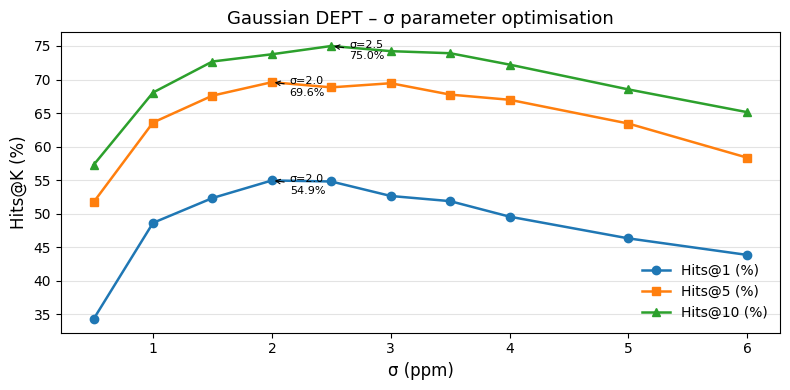

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

markers = ["o", "s", "^"]  # one per K value
for k, marker in zip(K_VALUES, markers):
    col = f"Hits@{k} (%)"
    ax.plot(
        summary_df.index,
        summary_df[col],
        marker=marker,
        label=col,
        linewidth=1.8,
    )
    # Annotate the optimal point
    best_sigma = summary_df[col].idxmax()
    best_val = summary_df[col].max()
    ax.annotate(
        f"σ={best_sigma:.1f}\n{best_val:.1f}%",
        xy=(best_sigma, best_val),
        xytext=(best_sigma + 0.15, best_val - 2),
        fontsize=8,
        arrowprops=dict(arrowstyle="->", lw=0.8),
    )

ax.set_xlabel("σ (ppm)", fontsize=12)
ax.set_ylabel("Hits@K (%)", fontsize=12)
ax.set_title("Gaussian DEPT – σ parameter optimisation", fontsize=13)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.35)
fig.tight_layout()

fig_path = OPT_DIR / "sigma_sweep_hits_at_k.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Figure saved → {fig_path}")
plt.show()

## 7 · Identify optimal σ per K

In [8]:
print("Optimal σ per metric:")
for k in K_VALUES:
    col = f"Hits@{k} (%)"
    best_sigma = summary_df[col].idxmax()
    best_val = summary_df[col].max()
    print(f"  Hits@{k:2d}: σ = {best_sigma:.1f} ppm  →  {best_val:.2f}%")

Optimal σ per metric:
  Hits@ 1: σ = 2.0 ppm  →  54.94%
  Hits@ 5: σ = 2.0 ppm  →  69.60%
  Hits@10: σ = 2.5 ppm  →  75.00%
